In [49]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

In [50]:
df = pd.read_excel('../data/monthly_avg.xlsx', parse_dates=['Date'], index_col='Date')
df.index = df.index.strftime('%m.%Y')
df_rounded = df.round(4)
df_rounded

,CHF,EUR,GPB,USD,AUD,UAH,NOK
Date,,,,,,,
06.2023,4.5448,4.4437,5.1751,4.0777,2.7129,0.1106,0.3779
07.2023,4.5988,4.4429,5.1749,4.0190,2.7063,0.1090,0.3913
08.2023,4.6529,4.4598,5.1946,4.0880,2.6514,0.1108,0.3908
09.2023,4.7908,4.5977,5.3353,4.3033,2.7645,0.1166,0.4013
10.2023,4.7249,4.5133,5.1986,4.2708,2.7136,0.1169,0.3886
11.2023,4.5668,4.3997,5.0545,4.0690,2.6442,0.1125,0.3729
12.2023,4.5883,4.3321,5.0269,3.9733,2.6552,0.1070,0.3758
01.2024,4.6625,4.3651,5.0839,4.0020,2.6600,0.1057,0.3849
02.2024,4.5747,4.3275,5.0646,4.0103,2.6177,0.1055,0.3800


In [51]:
df_rounded = df

In [52]:
print(df.describe())

             CHF        EUR        GPB        USD        AUD        UAH  \
count  13.000000  13.000000  13.000000  13.000000  13.000000  13.000000   
mean    4.570774   4.392033   5.113646   4.058381   2.663182   0.107490   
std     0.122736   0.094719   0.096443   0.109582   0.048520   0.005906   
min     4.353320   4.279990   5.000565   3.958525   2.597471   0.099187   
25%     4.492800   4.324487   5.036119   4.002009   2.623485   0.102305   
50%     4.574667   4.365123   5.083909   4.012227   2.655226   0.107037   
75%     4.652927   4.443683   5.175117   4.077667   2.706262   0.110814   
max     4.790752   4.597733   5.335324   4.303348   2.764457   0.116918   

             NOK  
count  13.000000  
mean    0.380947  
std     0.009845  
min     0.368305  
25%     0.373733  
50%     0.378107  
75%     0.388564  
max     0.401319  


In [53]:
#LOOKING_FOR_THE_HIGHEST_AND_SMALLEST_VALUE_FOR_SPECIFIC_CURRENCIES:

In [54]:
def get_max_min(df, column):
    max_date = df[column].idxmax()
    max_value = df.loc[max_date, column]
    min_date = df[column].idxmin()
    min_value = df.loc[min_date, column]
    return {'currency': column, 'max_date': max_date, 'max_value': max_value, 'min_date': min_date, 'min_value': min_value}

In [55]:
results = []
for col in df.columns:
    results.append(get_max_min(df, col))

In [56]:
df_high_low = pd.DataFrame(results)
df_high_low.set_index('currency', inplace=True)
df_high_low

,max_date,max_value,min_date,min_value
currency,,,,
CHF,09.2023,4.790752,05.2024,4.353320
EUR,09.2023,4.597733,05.2024,4.279990
GPB,09.2023,5.335324,05.2024,5.000565
USD,09.2023,4.303348,05.2024,3.958525
AUD,09.2023,2.764457,03.2024,2.597471
UAH,10.2023,0.116918,06.2024,0.099187
NOK,09.2023,0.401319,04.2024,0.368305


In [57]:
df_high_low.to_excel('../data/high_low.xlsx')

In [58]:
#CALCULATING_PERCENTAGE_CHANGES:

In [59]:
df_pct_change = df.pct_change().dropna()*(100)
df_pct_change_r = df_pct_change.round(2)
df_pct_change_r

,CHF,EUR,GPB,USD,AUD,UAH,NOK
Date,,,,,,,
07.2023,1.19,-0.02,-0.00,-1.44,-0.24,-1.43,3.55
08.2023,1.18,0.38,0.38,1.72,-2.03,1.66,-0.13
09.2023,2.96,3.09,2.71,5.27,4.26,5.18,2.70
10.2023,-1.38,-1.84,-2.56,-0.76,-1.84,0.31,-3.18
11.2023,-3.35,-2.52,-2.77,-4.73,-2.56,-3.78,-4.04
12.2023,0.47,-1.54,-0.55,-2.35,0.42,-4.86,0.79
01.2024,1.62,0.76,1.13,0.72,0.18,-1.22,2.43
02.2024,-1.88,-0.86,-0.38,0.21,-1.59,-0.25,-1.28
03.2024,-2.49,-0.46,-0.56,-1.16,-0.77,-3.00,-1.65


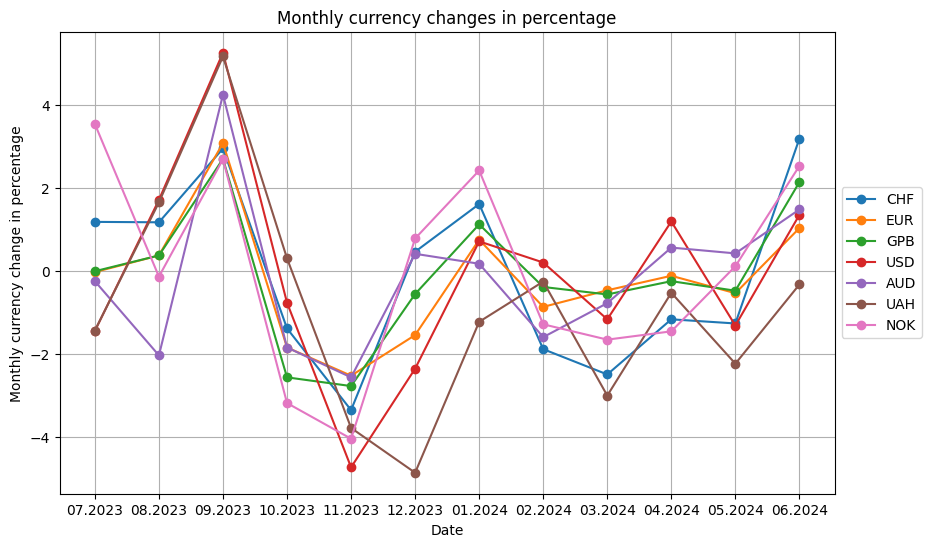

In [60]:
plt.figure(figsize=(10, 6))

plt.plot(df_pct_change_r.index, df_pct_change_r['CHF'], label='CHF', marker='o')
plt.plot(df_pct_change_r.index, df_pct_change_r['EUR'], label='EUR', marker='o')
plt.plot(df_pct_change_r.index, df_pct_change_r['GPB'], label='GPB', marker='o')
plt.plot(df_pct_change_r.index, df_pct_change_r['USD'], label='USD', marker='o')
plt.plot(df_pct_change_r.index, df_pct_change_r['AUD'], label='AUD', marker='o')
plt.plot(df_pct_change_r.index, df_pct_change_r['UAH'], label='UAH', marker='o')
plt.plot(df_pct_change_r.index, df_pct_change_r['NOK'], label='NOK', marker='o')

plt.title('Monthly currency changes in percentage')
plt.xlabel('Date')
plt.ylabel('Monthly currency change in percentage')

step = 0,2
yticks_values = np.arange(-5.0, 5.0, 0.1)

plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))

plt.grid(True)
plt.savefig('../data/currency_changes_in_percentage.pdf')
plt.show()

In [61]:
df_pct_change.to_excel('../data/percent_changes.xlsx')

In [62]:
#CORRELATION_MATRIX:

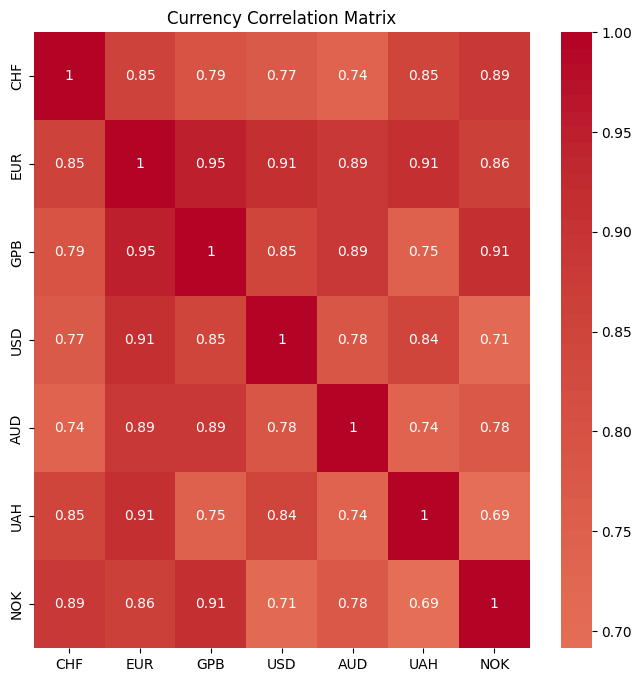

In [63]:
correlation_matrix = df.corr()

plt.figure(figsize=(8, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0)
plt.title('Currency Correlation Matrix')
plt.savefig('../data/currency_corelation_matrix.pdf')
plt.show()